In [1]:
import os
import json
import numpy as np
import librosa

In [2]:
# Define Correct Paths
BASE_PATH = "/kaggle/input/datasets/accelotron/nsynth-wav/nsynth-train-all"

AUDIO_PATH = os.path.join(BASE_PATH, "audio")
JSON_PATH = os.path.join(BASE_PATH, "examples-train-original.json")

print("Audio Path Exists:", os.path.exists(AUDIO_PATH))
print("JSON Path Exists:", os.path.exists(JSON_PATH))

Audio Path Exists: True
JSON Path Exists: True


In [3]:
#Load JSON Metadata
with open(JSON_PATH, "r") as f:
    metadata = json.load(f)

print("Total samples in JSON:", len(metadata))

Total samples in JSON: 289205


In [4]:
# Select Few Instruments
selected_families = ["keyboard", "guitar", "bass", "string", "brass", "reed"]

filtered_files = []

for file_id, info in metadata.items():
    if info["instrument_family_str"] in selected_families:
        filtered_files.append((file_id, info["instrument_family_str"]))

print("Filtered samples:", len(filtered_files))

# Create label mapping
label_map = {name: idx for idx, name in enumerate(selected_families)}

print(label_map)

Filtered samples: 196045
{'keyboard': 0, 'guitar': 1, 'bass': 2, 'string': 3, 'brass': 4, 'reed': 5}


In [5]:
# Load One Audio File
file_id, label = filtered_files[100]

file_path = os.path.join(AUDIO_PATH, file_id + ".wav")

audio, sr = librosa.load(file_path, sr=None)

print("Sampling Rate:", sr)
print("Audio Shape:", audio.shape)
print("Label:", label)

Sampling Rate: 16000
Audio Shape: (64000,)
Label: keyboard


In [6]:
# Trim Silence
audio_trimmed, _ = librosa.effects.trim(audio)

print("Original length:", len(audio))
print("Trimmed length:", len(audio_trimmed))

Original length: 64000
Trimmed length: 50176


In [7]:
# RMS Normalization
def rms_normalize(signal, target_rms=0.1):
    rms = np.sqrt(np.mean(signal**2))
    return signal * (target_rms / rms)

audio_normalized = rms_normalize(audio_trimmed)

# Check new RMS
new_rms = np.sqrt(np.mean(audio_normalized**2))
print("New RMS:", new_rms)

New RMS: 0.10000001


In [8]:
# Convert Audio → Mel-Spectrogram

import matplotlib.pyplot as plt
import librosa.display

mel_spec = librosa.feature.melspectrogram(
    y=audio_normalized,
    sr=sr,
    n_mels=128
)

print("Mel Spectrogram Shape:", mel_spec.shape)


Mel Spectrogram Shape: (128, 99)


In [9]:
# Apply Log Scaling (Convert to dB)

mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

print("After Log Scaling Shape:", mel_spec_db.shape)

After Log Scaling Shape: (128, 99)


In [10]:
# Feature Standardization

mean = np.mean(mel_spec_db)
std = np.std(mel_spec_db)

mel_spec_std = (mel_spec_db - mean) / std

print("New Mean:", np.mean(mel_spec_std))
print("New Std:", np.std(mel_spec_std))

New Mean: -2.8417568e-07
New Std: 0.99999994


In [11]:
num_classes = len(selected_families)

SAMPLE_RATE = 16000
SEGMENT_DURATION = 3
SEGMENT_LENGTH = SAMPLE_RATE * SEGMENT_DURATION
STEP = SEGMENT_LENGTH // 2
FIXED_LENGTH = 128

import random

X = []
Y = []

for file_id, label in filtered_files[:12000]:

    file_path = os.path.join(AUDIO_PATH, file_id + ".wav")

    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    audio, _ = librosa.effects.trim(audio)
    audio = rms_normalize(audio)

    labels = [label]

    # 🔥 CONTROLLED MIXING (FIXED)
    if np.random.rand() < 0.2:   # ↓ reduced
        file2, label2 = random.choice(filtered_files)
        audio2, _ = librosa.load(os.path.join(AUDIO_PATH, file2 + ".wav"), sr=SAMPLE_RATE)
        audio2, _ = librosa.effects.trim(audio2)
        audio2 = rms_normalize(audio2)

        min_len = min(len(audio), len(audio2))
        audio = audio[:min_len]
        audio2 = audio2[:min_len]

        mix_ratio = np.random.uniform(0.4, 0.6)
        audio = mix_ratio * audio + (1 - mix_ratio) * audio2

        labels.append(label2)

    # 🔥 SEGMENTATION (ADDED)
    for start in range(0, len(audio) - SEGMENT_LENGTH + 1, STEP):

        segment = audio[start:start+SEGMENT_LENGTH]

        # remove weak segments
        if np.mean(np.abs(segment)) < 0.01:
            continue

        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_mels=128,
            n_fft=2048,
            hop_length=256
        )

        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-6)

        # fix size
        if mel_db.shape[1] < FIXED_LENGTH:
            pad = FIXED_LENGTH - mel_db.shape[1]
            mel_db = np.pad(mel_db, ((0, 0), (0, pad)), mode='constant')
        else:
            mel_db = mel_db[:, :FIXED_LENGTH]

        # single channel (old model expects this)
        mel_db = np.expand_dims(mel_db, axis=-1)

        X.append(mel_db)

        multi_label = np.zeros(num_classes)
        for l in labels:
            multi_label[label_map[l]] = 1

        Y.append(multi_label)

X = np.array(X)
Y = np.array(Y)

# normalize
X = (X - X.mean()) / (X.std() + 1e-6)

print("Total segments:", len(X))

Total segments: 9109


In [12]:
# Convert Labels to Numbers

# Create label mapping
label_map = {name: idx for idx, name in enumerate(selected_families)}

print("Label Map:", label_map)

Label Map: {'keyboard': 0, 'guitar': 1, 'bass': 2, 'string': 3, 'brass': 4, 'reed': 5}


In [13]:
X = np.array(X)
Y = np.array(Y)

X = X[..., np.newaxis]

print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (9109, 128, 128, 1, 1)
Y shape: (9109, 6)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp,
    test_size=0.5,
    random_state=42,
    stratify=Y_temp
)


# Compute mean and std ONLY from training set
train_mean = np.mean(X_train)
train_std = np.std(X_train)

# Apply same normalization to all sets
# X_train = (X_train - train_mean) / train_std
# X_val   = (X_val - train_mean) / train_std
# X_test  = (X_test - train_mean) / train_std

# print("Normalization Done Properly")



print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (7287, 128, 128, 1, 1)
Validation: (911, 128, 128, 1, 1)
Test: (911, 128, 128, 1, 1)


In [15]:
# Applied two Augmentation...

# #Pitch shifting
# audio_pitch = librosa.effects.pitch_shift(audio, sr=sr, n_steps=1)


# # Adding background noise
# noise = 0.005 * np.random.randn(len(audio))
# audio_noise = audio + noise


import random
import numpy as np

def augment_sample(mel_spec):
    
    # Add stronger noise
    if random.random() < 0.5:
        noise = np.random.normal(0, 0.03, mel_spec.shape)
        mel_spec = mel_spec + noise

    # Time shift
    if random.random() < 0.5:
        shift = random.randint(-20, 20)
        mel_spec = np.roll(mel_spec, shift, axis=1)

    # Time masking
    if random.random() < 0.5:
        t = random.randint(10, 25)
        t0 = random.randint(0, mel_spec.shape[1] - t)
        mel_spec[:, t0:t0+t] = 0

    # Frequency masking
    if random.random() < 0.5:
        f = random.randint(5, 15)
        f0 = random.randint(0, mel_spec.shape[0] - f)
        mel_spec[f0:f0+f, :] = 0

    return mel_spec


augmented_X = []
augmented_Y = []

for i in range(len(X_train)):
    mel = X_train[i]
    label = Y_train[i]

    # original
    augmented_X.append(mel)
    augmented_Y.append(label)

    # augmented
    mel_aug = augment_sample(mel.copy())
    augmented_X.append(mel_aug)
    augmented_Y.append(label)

X_train = np.array(augmented_X)
Y_train = np.array(augmented_Y)

print("New X_train shape:", X_train.shape)

New X_train shape: (14574, 128, 128, 1, 1)


## My observation

After applying pitch shifting, the harmonic structure in the spectrogram shifted slightly upward in frequency while maintaining the overall timbre pattern.

After adding background noise, the waveform showed small fluctuations and the spectrogram displayed mild background energy increase.

Overall, the augmentation techniques introduced controlled variations without altering the fundamental identity of the instrument, thereby enhancing data diversity while maintaining label consistency.

In [16]:
# Apply same normalization to all sets
X_train = (X_train - train_mean) / train_std
X_val   = (X_val - train_mean) / train_std
X_test  = (X_test - train_mean) / train_std

print("Normalization Done Properly")

Normalization Done Properly


In [17]:
num_classes = Y_train.shape[1]
print("Number of classes:", num_classes)


# Training structure...

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.regularizers import l2

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1), kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# model.add(Conv2D(256, (3,3), activation='relu'))
# model.add(BatchNormalization())
# model.add(MaxPooling2D((2,2)))

model.add(GlobalAveragePooling2D())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(num_classes, activation='sigmoid'))

# Using Adam Optimizer------------------------------------
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)



# Using SGD optimizer ------------------------------------
# from tensorflow.keras.optimizers import SGD

# model.compile(
#     optimizer=SGD(learning_rate=0.01, momentum=0.9),
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )



# Using RMSprop optimizer -------------------------------
# from tensorflow.keras.optimizers import RMSprop

# model.compile(
#     optimizer=RMSprop(learning_rate=0.0003),
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )



model.summary()

Number of classes: 6


2026-03-18 09:20:21.622253: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773825621.866365      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773825621.937241      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773825622.534936      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773825622.534962      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773825622.534965      55 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,134 (500.52 KB)

 Trainable params: 127,686 (498.77 KB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
# Used Callbacks

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=3, factor=0.3)


# Train the model...

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
456/456 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7483 - loss: 0.2390 - val_accuracy: 0.7212 - val_loss: 0.2606 - learning_rate: 3.0000e-04
Epoch 2/15
456/456 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.7603 - loss: 0.2278 - val_accuracy: 0.6981 - val_loss: 0.2676 - learning_rate: 3.0000e-04
Epoch 3/15
456/456 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.7674 - loss: 0.2196 - val_accuracy: 0.6564 - val_loss: 0.2951 - learning_rate: 3.0000e-04
Epoch 4/15
456/456 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.7858 - loss: 0.2058 - val_accuracy: 0.7201 - val_loss: 0.2585 - learning_rate: 3.0000e-04
Epoch 5/15
456/456 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7929 - loss: 0.2024 - val_accuracy: 0.7146 - val_loss: 0.2753 - learning_rate: 3.0000e-04
Epoch 6/15
456/456 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8031 - loss: 0.1939 - val_accuracy: 0.7179 - val_loss: 0.2702 - learning_rate: 3.0000e-04
Epoch 7/15
456/456 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - ac

In [21]:
test_loss, test_acc = model.evaluate(X_test, Y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7709 - loss: 0.2361
Test Accuracy: 0.7716794610023499
Test Loss: 0.244503453373909


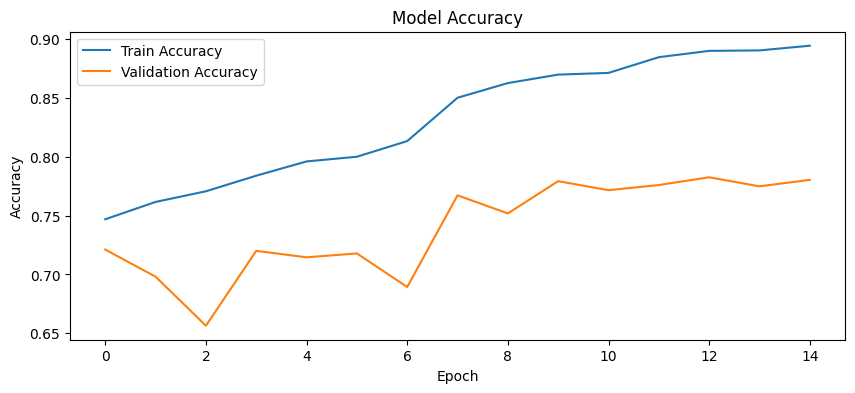

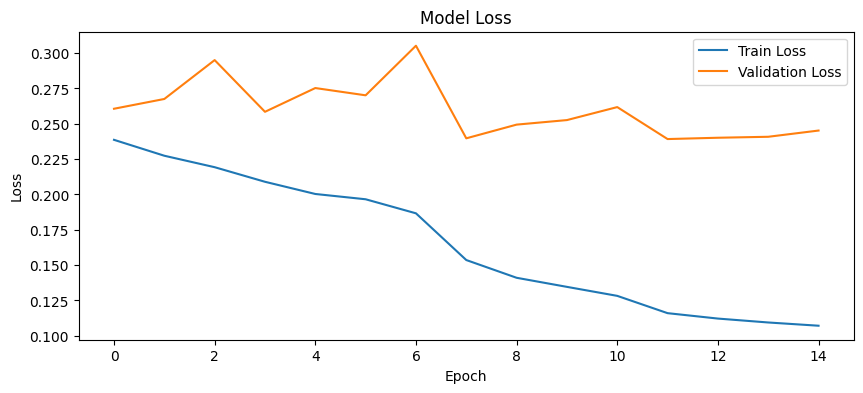

In [22]:
import matplotlib.pyplot as plt

# Accuracy Curve
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# Loss Curve
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [23]:
# Get Predictions
Y_pred = model.predict(X_test)

# ⃣Apply Threshold (Very Important)
threshold = 0.5
Y_pred_binary = (Y_pred >= threshold).astype(int)

# Now shapes

print("Y_test shape:", Y_test.shape)
print("Y_pred_binary shape:", Y_pred_binary.shape)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Y_test shape: (911, 6)
Y_pred_binary shape: (911, 6)


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    Y_test,
    Y_pred_binary,
    target_names=selected_families
))

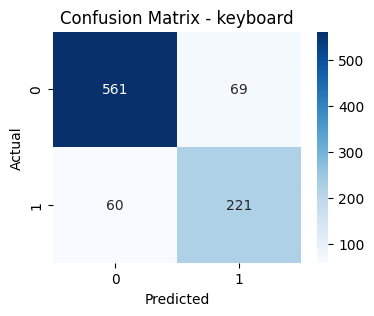

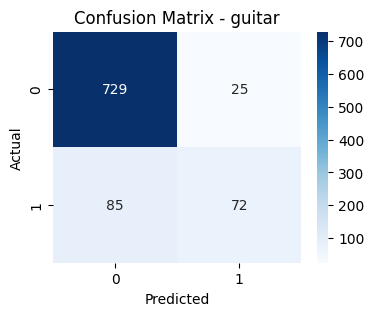

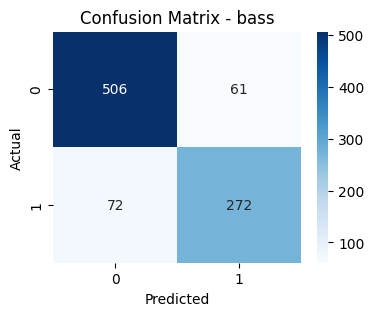

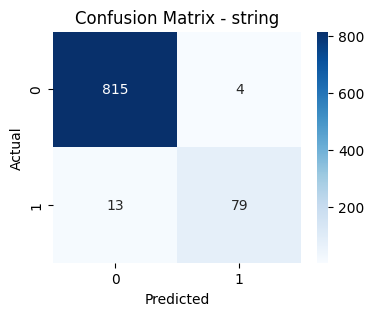

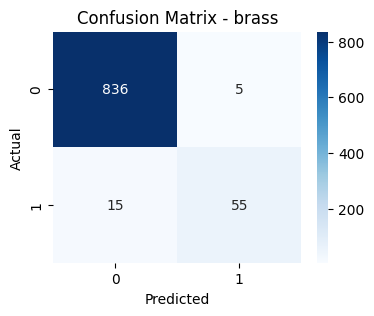

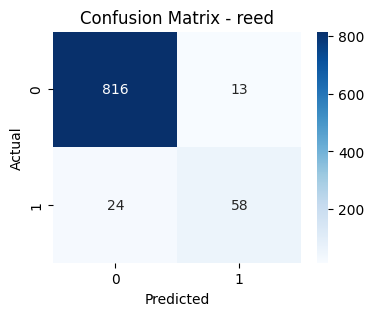

In [24]:
# Multilabel Confusion Matrix

from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

mcm = multilabel_confusion_matrix(Y_test, Y_pred_binary)

for i, matrix in enumerate(mcm):
    plt.figure(figsize=(4,3))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {selected_families[i]}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
# import os

# audio_path = "/kaggle/input/datasets/accelotron/nsynth-wav/nsynth-train-all/audio/"
# files = os.listdir(audio_path)

# def get_files_by_family(family, n=3):
#     selected = [f for f in files if f.startswith(family)]
#     return selected[:n]

# print("Bass files:", get_files_by_family("bass"))
# print("Guitar files:", get_files_by_family("guitar"))
# print("Keyboard files:", get_files_by_family("keyboard"))
# print("String files:", get_files_by_family("string"))
# print("Brass files:", get_files_by_family("brass"))
# print("Reed files:", get_files_by_family("reed"))

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


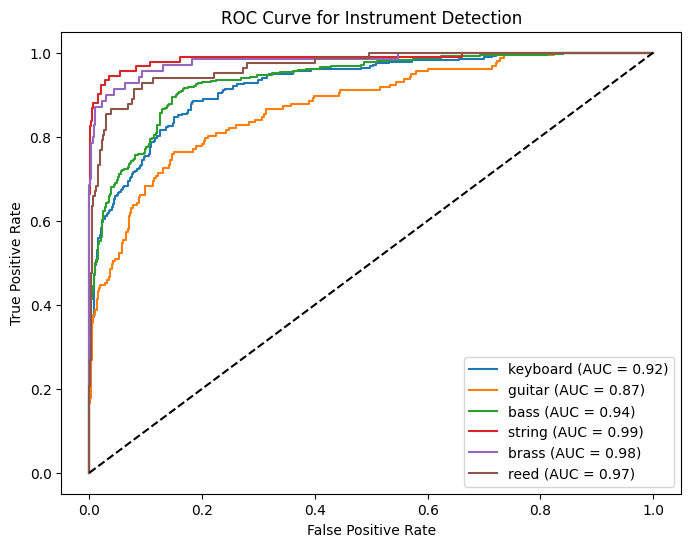

In [25]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Model predictions
Y_pred = model.predict(X_test)


# Plot ROC for each instrument
plt.figure(figsize=(8,6))

for i in range(num_classes):
    
    fpr, tpr, _ = roc_curve(Y_test[:, i], Y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{selected_families[i]} (AUC = {roc_auc:.2f})")

# Random baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Instrument Detection")
plt.legend()
plt.show()

In [27]:
# Evaluate model
test_loss, test_acc = model.evaluate(X_test, Y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

# Predictions
Y_pred = model.predict(X_test)

# 🔥 Better threshold (slightly tuned)
threshold = 0.3
Y_pred_binary = (Y_pred >= threshold).astype(int)

from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred_binary, target_names=selected_families))


# 🔥 Improved readable output
for i in range(5):

    actual_labels = [
        selected_families[j]
        for j in range(len(selected_families))
        if Y_test[i][j] == 1
    ]

    predicted_labels = [
        selected_families[j]
        for j in range(len(selected_families))
        if Y_pred_binary[i][j] == 1
    ]

    print("Actual:", actual_labels)
    print("Predicted:", predicted_labels)
    print("Probabilities:", np.round(Y_pred[i], 3))
    print("------")

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7709 - loss: 0.2361
Test Accuracy: 0.7716794610023499
Test Loss: 0.244503453373909
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

    keyboard       0.69      0.86      0.76       281
      guitar       0.64      0.57      0.61       157
        bass       0.79      0.87      0.83       344
      string       0.87      0.88      0.88        92
       brass       0.88      0.83      0.85        70
        reed       0.76      0.82      0.79        82

   micro avg       0.75      0.82      0.78      1026
   macro avg       0.77      0.80      0.79      1026
weighted avg       0.75      0.82      0.78      1026
 samples avg       0.80      0.85      0.80      1026

Actual: ['keyboard']
Predicted: ['keyboard']
Probabilities: [0.897 0.118 0.043 0.004 0.003 0.013]
------
Actual: ['bass']
Predicted: ['bass']
Probabilities: [0.018 0.194 0.871 0.    0.002 0.   ]
------
Actual: ['keyboard']
Predi

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
import numpy as np

# 1. Save the trained model
model.save('audio_classifier_model.keras')

# 2. Save the normalization values
np.save('train_mean.npy', train_mean)
np.save('train_std.npy', train_std)

print("Saved model and normalization values to disk!")

Saved model and normalization values to disk!


In [39]:
import librosa
import numpy as np
import tensorflow as tf

# Load the saved model and parameters ONCE at the top of your script
print("Loading model and parameters...")
MODEL = tf.keras.models.load_model('audio_classifier_model.keras')
TRAIN_MEAN = np.load('train_mean.npy')
TRAIN_STD = np.load('train_std.npy')
print("Ready!")

def predict_external_audio(file_path):
    # 1. Constants
    SAMPLE_RATE = 16000
    SEGMENT_DURATION = 3
    SEGMENT_LENGTH = SAMPLE_RATE * SEGMENT_DURATION
    FIXED_LENGTH = 128
    
    # 2. Load the external audio
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    
    # 3. Trim silence and apply RMS normalization
    audio, _ = librosa.effects.trim(audio)
    
    def rms_normalize(signal, target_rms=0.1):
        rms = np.sqrt(np.mean(signal**2))
        return signal * (target_rms / rms) if rms > 0 else signal
    
    audio = rms_normalize(audio)
    
    # 4. Take the first 3 seconds (or pad if it's shorter)
    if len(audio) > SEGMENT_LENGTH:
        segment = audio[:SEGMENT_LENGTH]
    else:
        segment = np.pad(audio, (0, SEGMENT_LENGTH - len(audio)), mode='constant')
        
    # 5. Convert to Mel-Spectrogram
    mel = librosa.feature.melspectrogram(
        y=segment,
        sr=SAMPLE_RATE,
        n_mels=128,
        n_fft=2048,
        hop_length=256
    )
    
    # 6. Apply Log Scaling and Local Feature Standardization
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-6)
    
    # 7. Fix time-axis length to your FIXED_LENGTH (128)
    if mel_db.shape[1] < FIXED_LENGTH:
        pad = FIXED_LENGTH - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad)), mode='constant')
    else:
        mel_db = mel_db[:, :FIXED_LENGTH]
        
    # 8. Reshape for the model (Add channel and batch dimensions)
    mel_db = np.expand_dims(mel_db, axis=-1)  
    X_input = np.array([mel_db])              
    
    # 9. Apply Global Normalization using the loaded parameters
    X_input = (X_input - TRAIN_MEAN) / TRAIN_STD
    
    # 10. Run the prediction using the loaded model
    predictions = MODEL.predict(X_input)
    
    # 11. Decode the labels mapping
    label_map = {'keyboard': 0, 'guitar': 1, 'bass': 2, 'string': 3, 'brass': 4, 'reed': 5}
    reverse_label_map = {v: k for k, v in label_map.items()}
    
    print(f"\n--- Predictions for {file_path} ---")
    for idx, prob in enumerate(predictions[0]):
        print(f"{reverse_label_map[idx]}: {prob*100:.2f}%")
        
    predicted_class_idx = np.argmax(predictions[0])
    print(f"\nTop Prediction: {reverse_label_map[predicted_class_idx]}")
    
    return predictions



Loading model and parameters...
Ready!


In [40]:
#need to provide the file path
predict_external_audio("/kaggle/input/datasets/subhojitdas1/gituar/freemusicforvideo-instrumental-acoustic-guitar-music-495627.mp3")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step

--- Predictions for /kaggle/input/datasets/subhojitdas1/gituar/freemusicforvideo-instrumental-acoustic-guitar-music-495627.mp3 ---
keyboard: 5.82%
guitar: 81.35%
bass: 75.57%
string: 4.48%
brass: 32.45%
reed: 0.54%

Top Prediction: guitar


array([[0.05816586, 0.81351066, 0.75566375, 0.04482402, 0.32454967,
        0.00543582]], dtype=float32)